# Data Understanding

## Import Libraries and Set Global Settings

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

## Define Data Sources

### Load Datasets

In [3]:
# Define Dataset Paths
datasets = {
    "uk_dataset": glob.glob("../data/raw/100,000 UK Used Car Data set/*.csv"),
    "andrei_dataset": "../data/raw/Used Cars Dataset Andrei Novikov/cars.csv",
    "uk_scrapped_data": "../data/raw/auto_trader_uk_scraped_cars_20260331_200824.csv"
}

# Assign dataframes variable
dfs = {}

# Iterate through datasets
for name, path in datasets.items():
    try:
        # Check if the path contains multiple files or is a single file
        if isinstance(path, list):
            # Read all files in the list, extract make, and concatenate them
            df_list = []
            for f in path:
                temp_df = pd.read_csv(f)
                
                # Extract filename without extension to use as the 'make'
                if name == "uk_dataset":
                    make_name = os.path.basename(f).replace('.csv', '').strip().lower()
                    
                    # Handle inconsistent make names from model named files (UK Dataset)
                    if make_name in ['merc', 'cclass']:
                        make_name = 'mercedes'
                    elif make_name == 'focus':
                        make_name = 'ford'
                        
                    # Add make names into the temporary dataframe
                    temp_df['make'] = make_name.capitalize()
                
                # Append the temporary dataframe with the updated make names to the dataframe list (UK Dataset)
                df_list.append(temp_df)
                
            # Append make names into a new feature in the dataset
            dfs[name] = pd.concat(df_list, ignore_index=True)
            
        else:
            # It's a single file path
            dfs[name] = pd.read_csv(path)
            
        # Output Dataset name and shape
        print(f"Loaded {name}: {dfs[name].shape[0]} rows, {dfs[name].shape[1]} columns.")
    except Exception as e:
        # Output Error if dataset not found
        print(f"Error loading {name}: {e}")

Loaded uk_dataset: 108540 rows, 10 columns.
Loaded andrei_dataset: 762091 rows, 20 columns.
Loaded uk_scrapped_data: 1999 rows, 10 columns.


### Optimize Datatypes

In [4]:
# Iterate through all dataframes in the dictionary to optimize their memory footprint
for name, df in dfs.items():
    # Calculate and store the initial memory usage in Megabytes (MB)
    initial_memory = df.memory_usage(deep=True).sum() / 1024**2
    
    # Identify all columns with 'object' (string) data types for conversion
    object_cols = df.select_dtypes(include='object').columns
    # Convert identified object columns to 'category' type to significantly reduce size
    df[object_cols] = df[object_cols].astype('category')
    
    # Identify columns containing 64-bit floating point numbers
    float_cols = df.select_dtypes(include=['float64']).columns
    # Downcast 64-bit floats to 32-bit to save space without losing relevant precision
    df[float_cols] = df[float_cols].astype('float32')
    
    # Identify columns containing 64-bit integers
    int_cols = df.select_dtypes(include=['int64']).columns
    # Downcast 64-bit integers to 32-bit to optimize integer storage
    df[int_cols] = df[int_cols].astype('int32')
    
    # Calculate and store the final memory usage after all optimizations are applied
    final_memory = df.memory_usage(deep=True).sum() / 1024**2
    
    # Output the memory reduction summary for each dataset to verify efficiency
    print(f"{name} Memory Usage: Reduced from {initial_memory:.2f} MB to {final_memory:.2f} MB")

uk_dataset Memory Usage: Reduced from 27.82 MB to 3.01 MB


/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_66706/426054863.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include='object').columns
/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_66706/426054863.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pand

andrei_dataset Memory Usage: Reduced from 505.35 MB to 44.94 MB
uk_scrapped_data Memory Usage: Reduced from 0.53 MB to 0.06 MB


/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_66706/426054863.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include='object').columns


### Output Sample from All Datasets

In [5]:
# Iterate through datasets
for i in dfs.keys():
    # Output Dataset Name
    print(f'\n{'='*20} {i} {'='*20}')
    # Output Samples of the dataset
    print(dfs[i].sample(5))


==================== uk_dataset ====================
            model  year  price transmission  mileage fuelType    tax  \
12322    Insignia  2018  14995       Manual    14888   Petrol  145.0   
35915      Tiguan  2016  14995    Semi-Auto    45413   Diesel  165.0   
38310      Arteon  2018  19998    Semi-Auto    20810   Petrol  145.0   
104452    A Class  2017  17699    Semi-Auto     6498   Petrol  145.0   
29930        Golf  2017  11500       Manual    34468   Petrol  150.0   

              mpg  engineSize      make  
12322   50.400002         1.5  Vauxhall  
35915   49.599998         2.0        Vw  
38310   47.099998         2.0        Vw  
104452  52.299999         1.6  Mercedes  
29930   54.299999         1.4        Vw  

==================== andrei_dataset ====================
         manufacturer                 model  year   mileage  \
39771             BMW                    X7  2020   22234.0   
169370          Dodge          Ram 2500 SLT  2011  130695.0   
12593         

## Data Source Documentation

In [6]:
# Document data source details for each dataset
data_source_report = {
    
    # 100,000 UK Dataset
    'uk_dataset': {
        'name': '100,000 UK Used Car Data set',
        'source': 'https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes',
        'acquisition_method': 'CSV download through kaggle.com (multiple files per car make)',
        'date_acquired': '2026',
        'issues_encountered': ['Multiple CSV files need merging', 'Inconsistent make names (cclass, merc, focus)', 'Missing EV related features']
    },
    
    # Andrei Novikov Dataset
    'andrei_dataset': {
        'name': 'Used Cars Dataset by Andrei Noviko',
        'source': 'https://www.kaggle.com/datasets/andreinovikov/used-cars-dataset',
        'acquisition_method': 'CSV download through kaggle.com',
        'date_acquired': '2026',
        'issues_encountered': ['Missing mpg and engineSize columns', 'US-based data (different market)', 'Missing EV related features']
    },

    # Andrei Novikov Dataset
    'uk_scraped_dataset': {
        'name': 'AutoTrader.co.uk',
        'source': 'https://www.autotrader.co.uk/car-search?advertising-location=at_cars&channel=cars&fuel-type=Electric&homeDeliveryAdverts=include&make=&postcode=SW1A%201AA&sort=relevance&year-to=2026',
        'acquisition_method': 'Data Scrapping using Playwright',
        'date_acquired': '2026',
        'issues_encountered': ['Bot Detection', 'Limited Pagination Functionality', "Missing EV related features"]
    }
}

# Print the documented data to console/output
for name, report in data_source_report.items():
    print(f"\n{'='*20} {name} {'='*20}")
    for key, value in report.items():
        print(f"  {key}: {value}")


==================== uk_dataset ====================
  name: 100,000 UK Used Car Data set
  source: https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes
  acquisition_method: CSV download through kaggle.com (multiple files per car make)
  date_acquired: 2026
  issues_encountered: ['Multiple CSV files need merging', 'Inconsistent make names (cclass, merc, focus)', 'Missing EV related features']

==================== andrei_dataset ====================
  name: Used Cars Dataset by Andrei Noviko
  source: https://www.kaggle.com/datasets/andreinovikov/used-cars-dataset
  acquisition_method: CSV download through kaggle.com
  date_acquired: 2026
  issues_encountered: ['Missing mpg and engineSize columns', 'US-based data (different market)', 'Missing EV related features']

==================== uk_scraped_dataset ====================
  name: AutoTrader.co.uk
  source: https://www.autotrader.co.uk/car-search?advertising-location=at_cars&channel=cars&fuel-type=Electr

## Describe Data

### Dataset Information

In [7]:
# Iterate through datasets
for name, df in dfs.items():
    # Output dataset name
    print(f"\n{'='*20} {name} {'='*20}")
    # Output dataset information
    print(df.info())


==================== uk_dataset ====================
<class 'pandas.DataFrame'>
RangeIndex: 108540 entries, 0 to 108539
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   model         108540 non-null  category
 1   year          108540 non-null  int32   
 2   price         108540 non-null  int32   
 3   transmission  108540 non-null  category
 4   mileage       108540 non-null  int32   
 5   fuelType      108540 non-null  category
 6   tax           99187 non-null   float32 
 7   mpg           99187 non-null   float32 
 8   engineSize    108540 non-null  float32 
 9   make          108540 non-null  category
dtypes: category(4), float32(3), int32(3)
memory usage: 3.0 MB
None

==================== andrei_dataset ====================
<class 'pandas.DataFrame'>
RangeIndex: 762091 entries, 0 to 762090
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --

### Numerical Statistics

In [8]:
# Iterate through datasets
for name, df in dfs.items():

    # Output dataset name header
    print(f"\n--- Numerical Statistics ({name}) ---")
    # Output dataset description
    print(df.describe()) 


--- Numerical Statistics (uk_dataset) ---
                year          price        mileage           tax  \
count  108540.000000  108540.000000  108540.000000  99187.000000   
mean     2017.098028   16890.124046   23025.928469    120.299835   
std         2.130057    9756.266820   21176.423684     63.150928   
min      1970.000000     450.000000       1.000000      0.000000   
25%      2016.000000   10229.500000    7491.750000    125.000000   
50%      2017.000000   14698.000000   17265.000000    145.000000   
75%      2019.000000   20940.000000   32236.000000    145.000000   
max      2060.000000  159999.000000  323000.000000    580.000000   

                mpg     engineSize  
count  99187.000000  108540.000000  
mean      55.166828       1.661644  
std       16.138523       0.557058  
min        0.300000       0.000000  
25%       47.099998       1.200000  
50%       54.299999       1.600000  
75%       62.799999       2.000000  
max      470.799988       6.600000  

--- Numeri

### Categorical Statistics

In [9]:
# Iterate through datasets
for name, df in dfs.items():

    # Categorical Overview
    if not df.select_dtypes(include=['object', 'category']).empty:

        # Output dataset name header
        print(f"\n--- Categorical Statistics ({name}) ---")
        # Output categorical feature Statistics
        print(df.describe(include=['object', 'category']))


--- Categorical Statistics (uk_dataset) ---
         model transmission fuelType    make
count   108540       108540   108540  108540
unique     195            4        5       9
top      Focus       Manual   Petrol    Ford
freq     10042        61308    59875   23419

--- Categorical Statistics (andrei_dataset) ---
       manufacturer      model                      engine       transmission  \
count        762091     762091                      747041             752187   
unique           30      12187                        6903               1313   
top            Ford  Fusion SE  2.0L I4 16V GDI DOHC Turbo  6-Speed Automatic   
freq          79526       3172                       75545             148597   

               drivetrain fuel_type     mpg exterior_color interior_color  \
count              740529    739164  620020         753232         705116   
unique                 33        36     865           7681           4679   
top     Front-wheel Drive  Gasoline   19-26 

In [10]:
# Iterate through datasets
for name, df in dfs.items():

    # Output dataset name header
    print(f"\n--- {name} Object Count ---")

    # Identify object-type columns in the current dataframe
    object_cols = df.select_dtypes(include=['object', 'category']).columns
    
    # Check if object columns exist before iterating
    if len(object_cols) > 0:
        # Iterate through identified categorical columns
        for col in object_cols:
            # Output column name header
            print(f"\n--- {col} ---")
            
            # Output top 20 value counts for the specific column
            print(df[col].value_counts().head(20)) 
    else:
        # Output message if no object columns are present in the dataset
        print(f"No object-type columns found in {name}.")


--- uk_dataset Object Count ---

--- model ---
model
Focus       10042
C Class      7646
Fiesta       6557
Golf         4863
Corsa        3441
Polo         3287
Astra        2805
A Class      2561
3 Series     2443
Kuga         2225
Mokka X      2127
Yaris        2122
1 Series     1969
Aygo         1961
E Class      1953
A3           1929
Tiguan       1765
Fabia        1571
Octavia      1477
Q3           1417
Name: count, dtype: int64

--- transmission ---
transmission
Manual       61308
Semi-Auto    24903
Automatic    22319
Other           10
Name: count, dtype: int64

--- fuelType ---
fuelType
Petrol      59875
Diesel      45177
Hybrid       3229
Other         253
Electric        6
Name: count, dtype: int64

--- make ---
make
Ford        23419
Mercedes    17018
Vw          15157
Vauxhall    13632
Bmw         10781
Audi        10668
Toyota       6738
Skoda        6267
Hyundi       4860
Name: count, dtype: int64

--- andrei_dataset Object Count ---

--- manufacturer ---
manufacturer
F

## Explore Data

### Define Colourblind Safe Colour Palette

In [11]:
okabe_ito = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

### UK Dataset

#### Univariate Analysis

##### Price and Milage Distribution

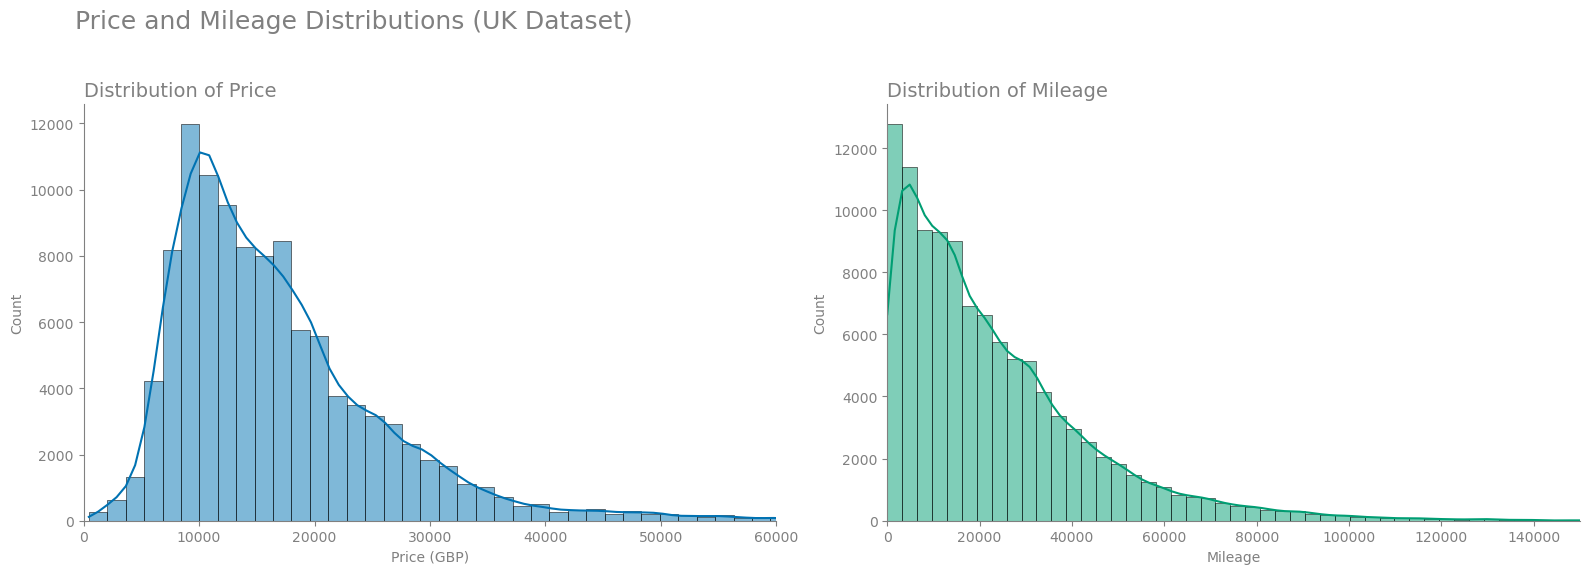

In [12]:
# Initialize subplots for price and mileage
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Set title for the combined plots - Aligned left to reduce eye-travel
fig.suptitle('Price and Mileage Distributions (UK Dataset)', 
             fontsize=18, x=0.05, ha='left', color='grey')

# Generate histogram and KDE for price - Using Okabe-Ito Blue
sns.histplot(dfs['uk_dataset']['price'], bins=100, kde=True, ax=axes[0], color=okabe_ito[4])
    
# Set individual plot title and axis labels for price - Using grey for labels
axes[0].set_title('Distribution of Price', loc='left', color='grey', fontsize=14)
axes[0].set_xlabel('Price (GBP)', color='grey')
axes[0].set_ylabel('Count', color='grey')
# Decrease x lim to focus on the main distribution (0 to 60k)
axes[0].set_xlim(0, 60000)

# Generate histogram and KDE for mileage - Using Okabe-Ito Green
sns.histplot(dfs['uk_dataset']['mileage'], bins=100, kde=True, ax=axes[1], color=okabe_ito[2])
    
# Set individual plot title and axis labels for mileage - Using grey for labels
axes[1].set_title('Distribution of Mileage', loc='left', color='grey', fontsize=14)
axes[1].set_xlabel('Mileage', color='grey')
axes[1].set_ylabel('Count', color='grey')
# Decrease x lim to focus on the main distribution (0 to 150k)
axes[1].set_xlim(0, 150000)

# Refine the visual interface by lightening spines and ticks to grey
for ax in axes:
    # Remove top and right lines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Lighten remaining spines to reduce visual noise
    ax.spines['left'].set_color('grey')
    ax.spines['bottom'].set_color('grey')
    
    # Set axis ticks and tick labels to grey for consistency
    ax.tick_params(axis='both', colors='grey')

# Adjust layout to prevent overlapping and display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save graph
plt.savefig('price_milage_dist_uk.png', dpi=300, bbox_inches='tight')

# Show histogram plots
plt.show()

##### Transmission and Fuel Type Count

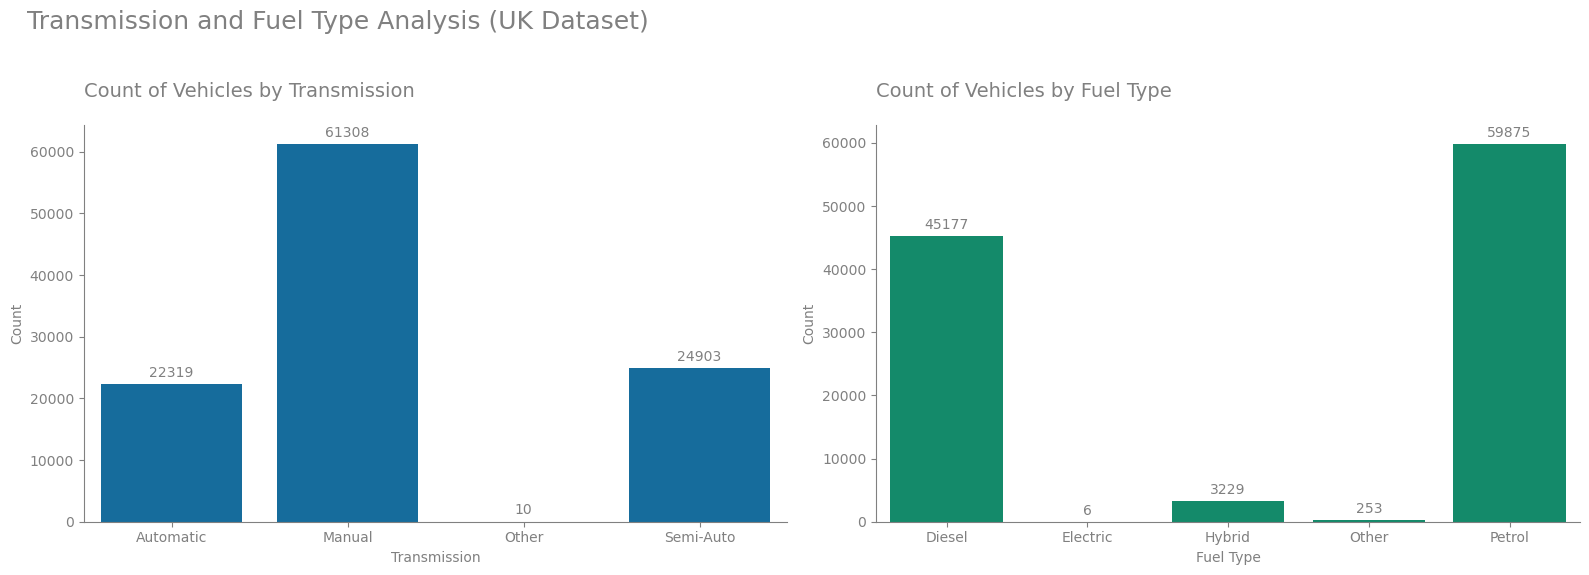

In [13]:
# Initialize subplots for transmission and fuel type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Set title for the categorical analysis plots - Aligned left to reduce eye-travel
fig.suptitle('Transmission and Fuel Type Analysis (UK Dataset)', 
             fontsize=18, x=0.02, ha='left', color='grey')

# Generate count plot for transmission types - Using Okabe-Ito palette for accessibility
sns.countplot(data=dfs['uk_dataset'], x='transmission', ax=axes[0], color=okabe_ito[4])
    
# Set individual plot title for transmission - Left-aligned for cleaner lines
axes[0].set_title('Count of Vehicles by Transmission', loc='left', color='grey', fontsize=14, pad=20)
axes[0].set_xlabel('Transmission', color='grey')
axes[0].set_ylabel('Count', color='grey')
    
# Annotate bars with frequency labels for better readability
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, color='grey')

# Generate count plot for fuel types - Using Okabe-Ito palette for accessibility
sns.countplot(data=dfs['uk_dataset'], x='fuelType', ax=axes[1], color=okabe_ito[2])
    
# Set individual plot title for fuel type - Left-aligned for cleaner lines
axes[1].set_title('Count of Vehicles by Fuel Type', loc='left', color='grey', fontsize=14, pad=20)
axes[1].set_xlabel('Fuel Type', color='grey')
axes[1].set_ylabel('Count', color='grey')
    
# Annotate bars with frequency labels
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, color='grey')

# Remove top and right lines and apply grey tones to reduce visual noise
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('grey')
    ax.spines['bottom'].set_color('grey')
    ax.tick_params(colors='grey')

# Adjust layout to optimize spacing between subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save graph
plt.savefig('transmission_fuelType_dist_uk.png', dpi=300, bbox_inches='tight')

# Show countplots
plt.show()

##### Make and Model Distribution

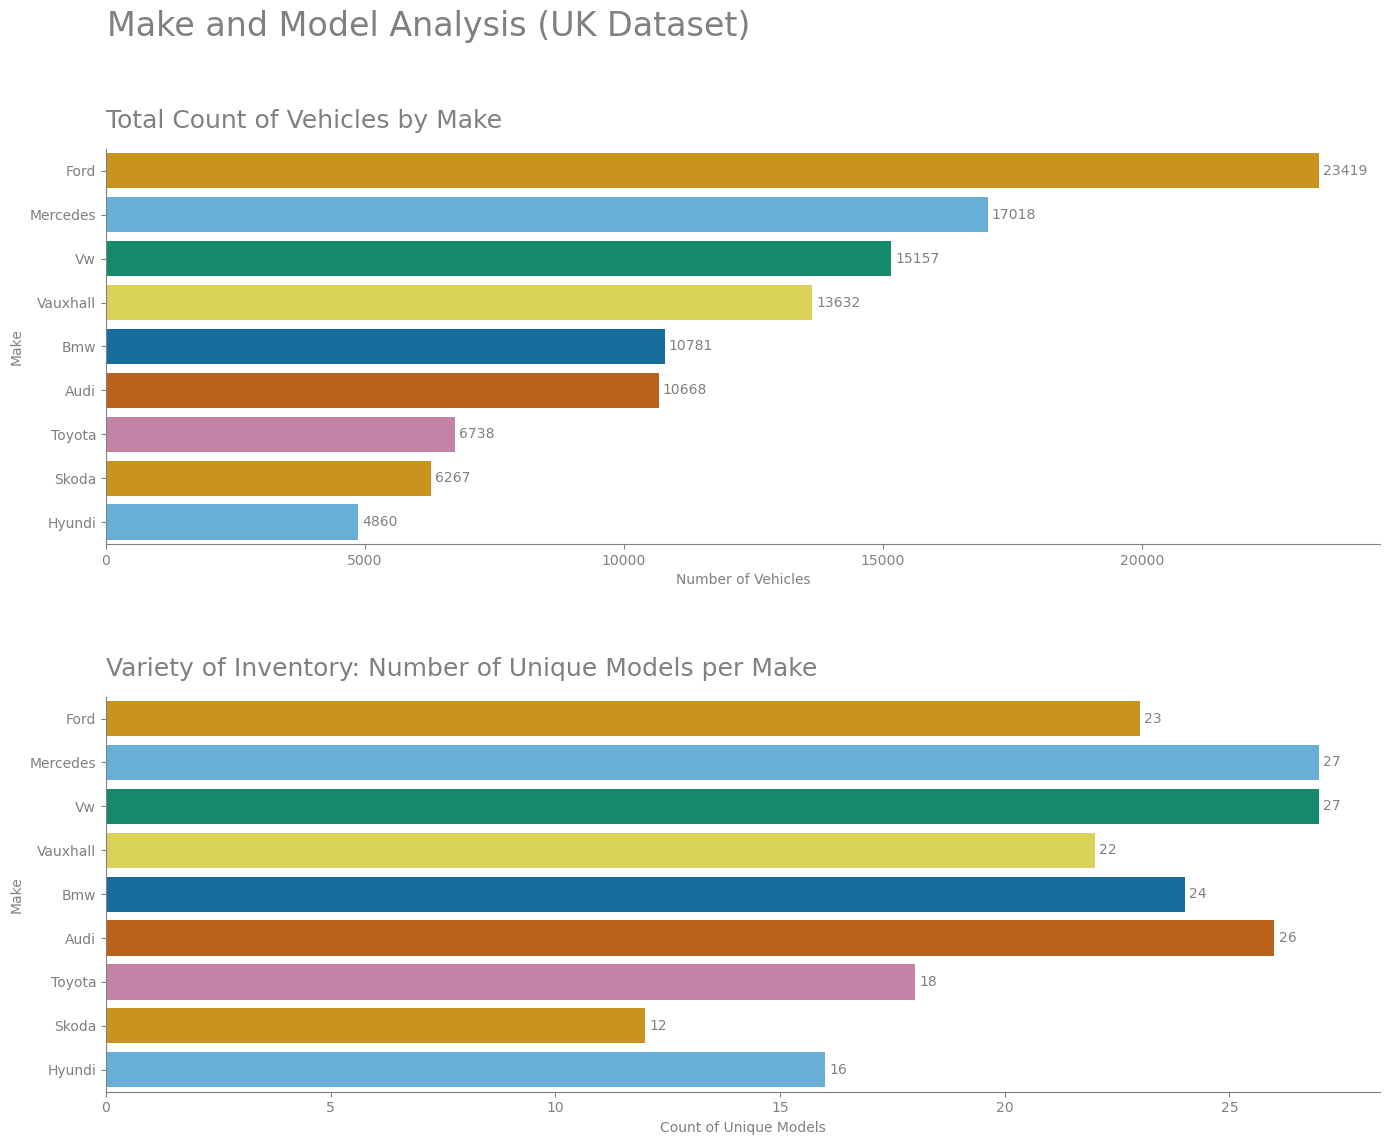

In [14]:
# Initialize subplots for make and model variety analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Set title for the make-level overview - Aligned left to reduce eye-travel
fig.suptitle('Make and Model Analysis (UK Dataset)', 
             fontsize=24, x=0.08, ha='left', color='grey')

# Determine the order of make by frequency - We will use this for BOTH graphs
make_order = dfs['uk_dataset']['make'].value_counts().index

# Create a color mapping that cycles through the palette
brand_palette = {make: okabe_ito[i % len(okabe_ito)] for i, make in enumerate(make_order)}
    
# 1. Top Plot: Total Count (Sorted by Frequency)
sns.countplot(data=dfs['uk_dataset'], y='make', order=make_order, 
              ax=axes[0], palette=brand_palette, hue='make', dodge=False, legend=False)
    
axes[0].set_title('Total Count of Vehicles by Make', loc='left', color='grey', fontsize=18, pad=15)
axes[0].set_xlabel('Number of Vehicles', color='grey')
axes[0].set_ylabel('Make', color='grey')
    
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, color='grey')

# 2. Bottom Plot: Unique Models (Now using the same 'make_order' as above)
unique_models = dfs['uk_dataset'].groupby('make')['model'].nunique()
    
sns.barplot(x=unique_models.values, y=unique_models.index, order=make_order,
            ax=axes[1], palette=brand_palette, hue=unique_models.index, dodge=False, legend=False)
    
axes[1].set_title('Variety of Inventory: Number of Unique Models per Make', loc='left', color='grey', fontsize=18, pad=15)
axes[1].set_xlabel('Count of Unique Models', color='grey')
axes[1].set_ylabel('Make', color='grey')
    
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, color='grey')

# Refine the visual interface by stripping clutter and applying grey tones
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('grey')
    ax.spines['bottom'].set_color('grey')
    ax.tick_params(colors='grey')

# Optimize layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=5.0)

# Save graph
plt.savefig('make_model_analysis_uk.png', dpi=300, bbox_inches='tight')

# Show barplots
plt.show()

#### Bivariate/Multivariate Analysis

##### Price by Make

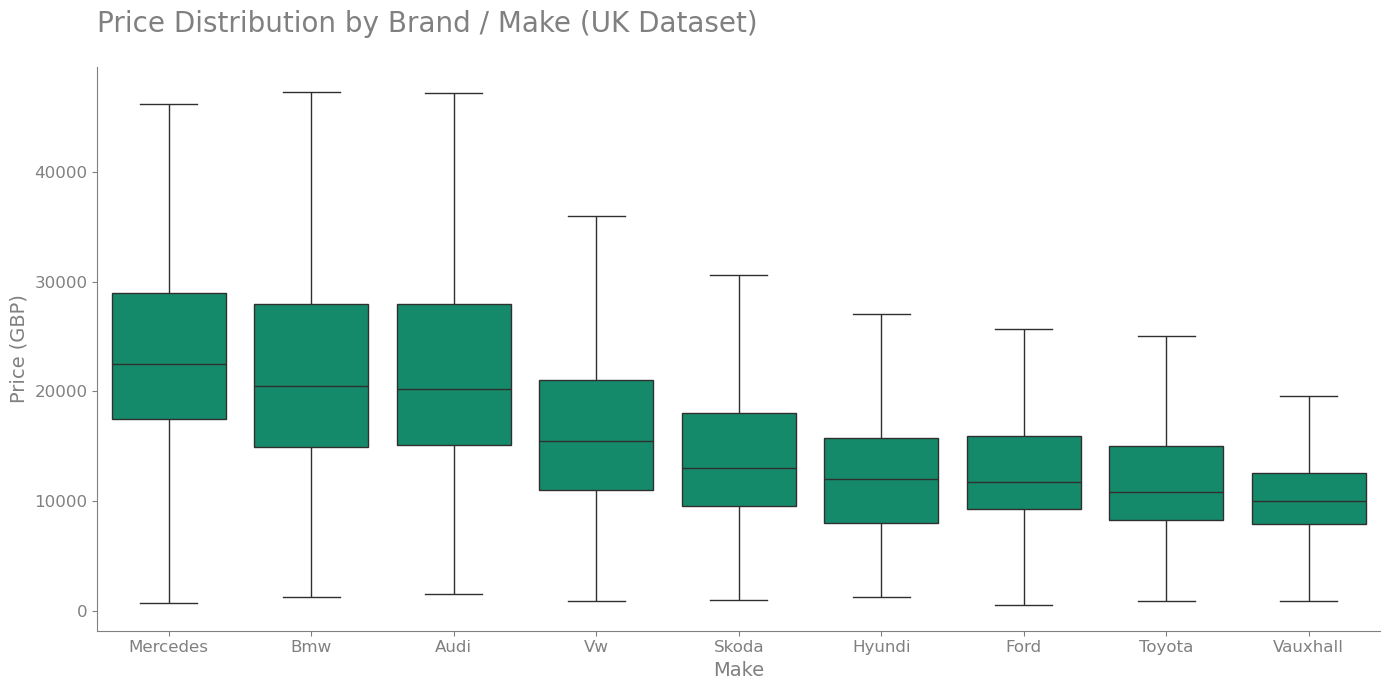

In [15]:
# Set the figure dimensions using the object-oriented interface for fine-tuning
fig, ax = plt.subplots(figsize=(14, 7))

# Calculate the median price per make and sort in descending order to organize the visualization
order = dfs['uk_dataset'].groupby('make')['price'].median().sort_values(ascending=False).index

# Generate boxplots using the Okabe-Ito palette for colourblind safety and accessibility
sns.boxplot(
    data=dfs['uk_dataset'], 
    x='make', 
    y='price', 
    order=order,
    color=okabe_ito[2], 
    showfliers=False,
    ax=ax
)

# Add a descriptive title aligned left to create clean lines and reduce eye-travel
ax.set_title('Price Distribution by Brand / Make (UK Dataset)', 
             loc='left', fontsize=20, color='grey', pad=25)

# Set axis labels with increased font size for better legibility
ax.set_xlabel('Make', color='grey', fontsize=14)
ax.set_ylabel('Price (GBP)', color='grey', fontsize=14)

# Ensure x-axis labels are horizontal (0 degrees) and increase tick label size
ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Remove top and right spines to apply the principle of Closure
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Lighten remaining spines and ticks so they recede behind the data
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Optimize layout to prevent overlapping and display the plot
plt.tight_layout()

# Save graph
plt.savefig('price_dist_make_uk.png', dpi=300, bbox_inches='tight')

# Show boxplot
plt.show()

##### Price vs Milage (Best Fit Line)

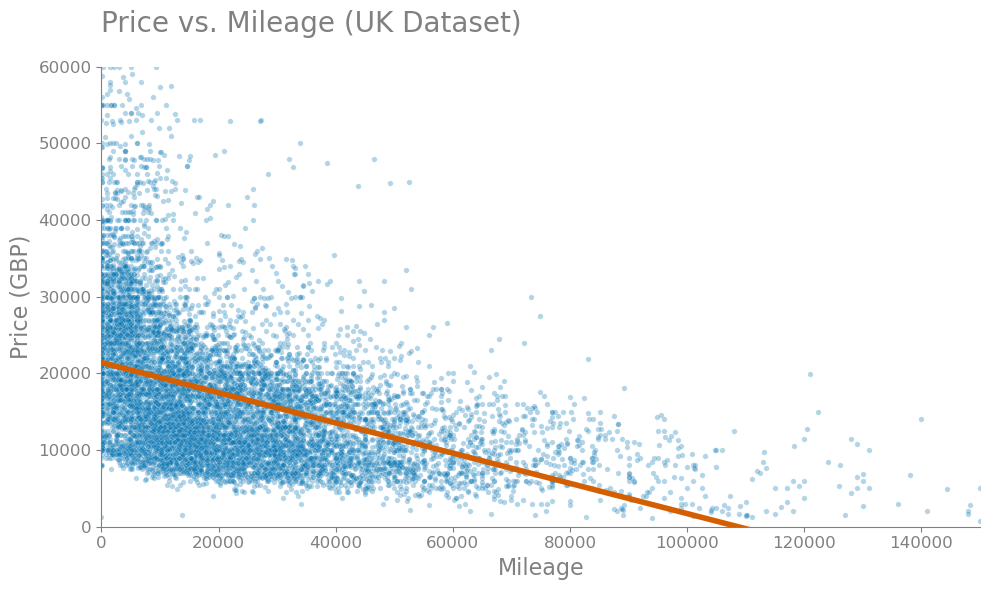

In [16]:
# Initialize subplots for price vs. mileage analysis
fig, ax = plt.subplots(figsize=(10, 6))

# Generate scatter plot using Okabe-Ito Blue
sns.scatterplot(
    data=dfs['uk_dataset'].sample(min(10000, len(dfs['uk_dataset']))), 
    x='mileage', y='price', alpha=0.3, s=15, color=okabe_ito[4], ax=ax, zorder=1
)

# Add a linear regression line in Okabe-Ito Vermillion to highlight the trend
sns.regplot(
    data=dfs['uk_dataset'], 
    x='mileage', 
    y='price', 
    scatter=False,
    color=okabe_ito[5], 
    line_kws={"linewidth": 4, "zorder": 5},
    ax=ax
)

# Set x and Y limit - Ensuring an ethical zero baseline for price 
ax.set_ylim(bottom=0, top=60000)
ax.set_xlim(0, 150000) 
    
# Add descriptive labels and title - Left-aligned for cleaner lines
ax.set_title('Price vs. Mileage (UK Dataset)', loc='left', fontsize=20, color='grey', pad=25)
ax.set_xlabel('Mileage', color='grey', fontsize=16)
ax.set_ylabel('Price (GBP)', color='grey', fontsize=16)

# Refine the visual interface by stripping clutter and applying grey tones
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Lighten remaining spines and increase tick label size for better legibility
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(axis='both', colors='grey', labelsize=12)

# Optimize layout to prevent overlapping and display the plot
plt.tight_layout()

# Save graph
plt.savefig('price_milage_uk.png', dpi=300, bbox_inches='tight')

# Show Scatterplot
plt.show()

##### Correlation Matrix

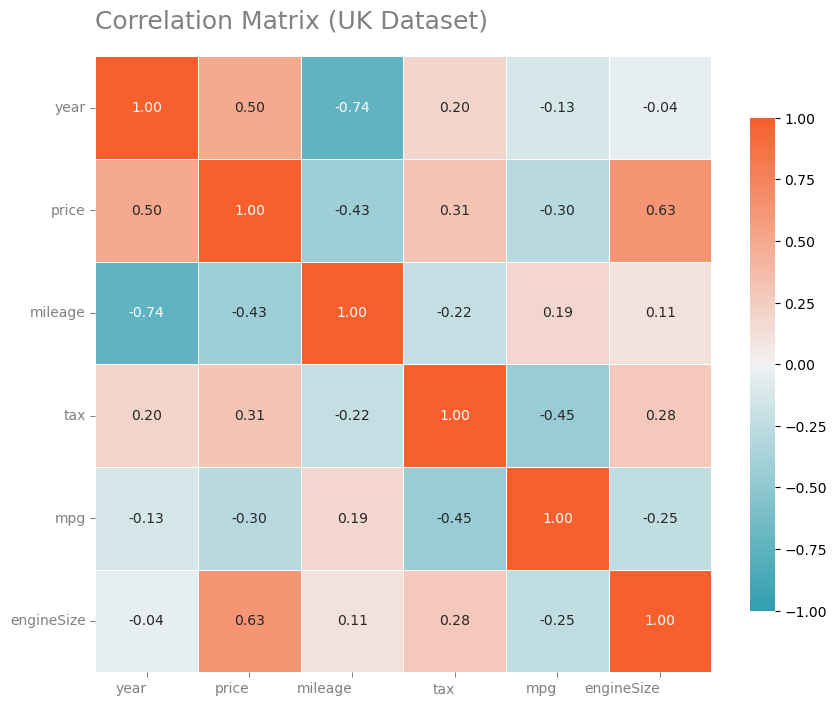

In [17]:
# Set figure size for the correlation heatmap using the object-oriented interface
fig, ax = plt.subplots(figsize=(10, 8))

# Identify numerical columns for correlation analysis
num_cols_uk = dfs['uk_dataset'].select_dtypes(include=[np.number]).columns

# Calculate the Pearson correlation coefficients for the numerical features
corr_uk = dfs['uk_dataset'][num_cols_uk].corr()

# Create a "High Visibility" colorblind-friendly diverging palette 
vibrant_cb_palette = sns.diverging_palette(h_neg=210, h_pos=20, s=90, l=60, as_cmap=True)

# Generate heatmap
sns.heatmap(
    corr_uk, 
    annot=True, 
    cmap=vibrant_cb_palette, 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    ax=ax
)

# Set the title
ax.set_title('Correlation Matrix (UK Dataset)', loc='left', color='grey', fontsize=18, pad=20)

# Refine axis ticks and labels
ax.tick_params(colors='grey')

# X-axis: Rotating 45 degrees (from previous step)
ax.set_xticklabels(ax.get_xticklabels(), ha='right', color='grey')

# Y-axis: Rotating 90 degrees as requested
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center', color='grey')

# Remove the outer spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Save graph
plt.savefig('heatmap_uk.png', dpi=300, bbox_inches='tight')

# Show heatmap
plt.show()

##### Price vs Milage Hexbin

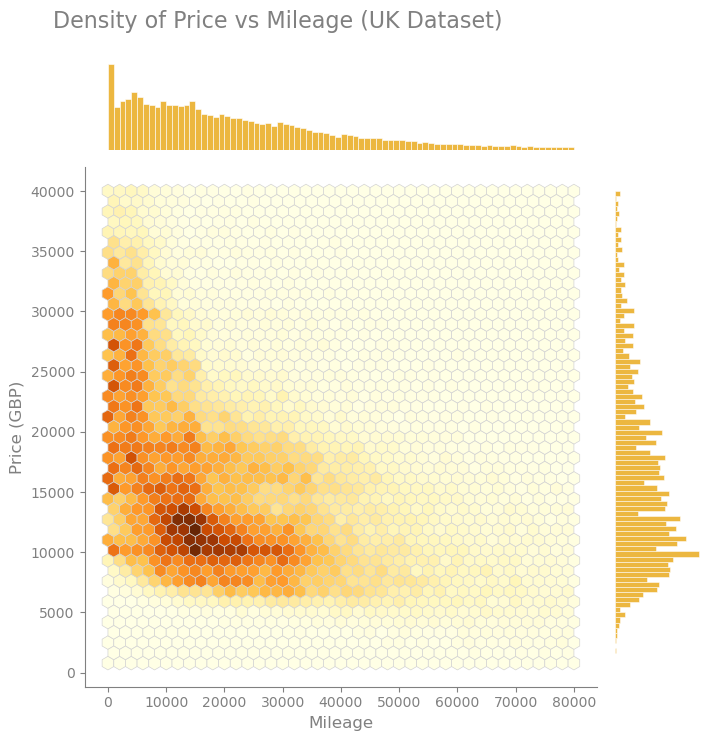

In [18]:
# Create a hex mask for price < 40000 and milage < 80000
uk_hex_mask = (dfs['uk_dataset']['price'] < 40000) & (dfs['uk_dataset']['mileage'] < 80000)

# Extract price and milage data
uk_hex_data = dfs['uk_dataset'][uk_hex_mask]

# Generate hexbin plot using jointplot with outlines added to the hexbins
hb = sns.jointplot(
    data=uk_hex_data, 
    x='mileage', 
    y='price', 
    kind='hex', 
    cmap='YlOrBr', 
    gridsize=40, 
    height=7,
    joint_kws={'edgecolors': 'lightgrey', 'linewidths': 0.5},
    marginal_kws={'color': okabe_ito[0], 'edgecolor': 'white'}
)

# Set axis labels
hb.ax_joint.set_xlabel('Mileage', color='grey', fontsize=12)
hb.ax_joint.set_ylabel('Price (GBP)', color='grey', fontsize=12)

# Set graph title
plt.suptitle("Density of Price vs Mileage (UK Dataset)", 
             x=0.05, y=1.05, ha='left', fontsize=16, color='grey')

# Remove top and right lines
hb.ax_joint.spines['top'].set_visible(False)
hb.ax_joint.spines['right'].set_visible(False)
hb.ax_joint.spines['left'].set_color('grey')
hb.ax_joint.spines['bottom'].set_color('grey')
hb.ax_joint.tick_params(colors='grey')

# Clean up marginal axes
for ax in [hb.ax_marg_x, hb.ax_marg_y]:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='grey', length=0)

# Save graph
plt.savefig('hex_price_milage_uk.png', dpi=300, bbox_inches='tight')

# Show hexbin
plt.show()

##### Price by Transmission

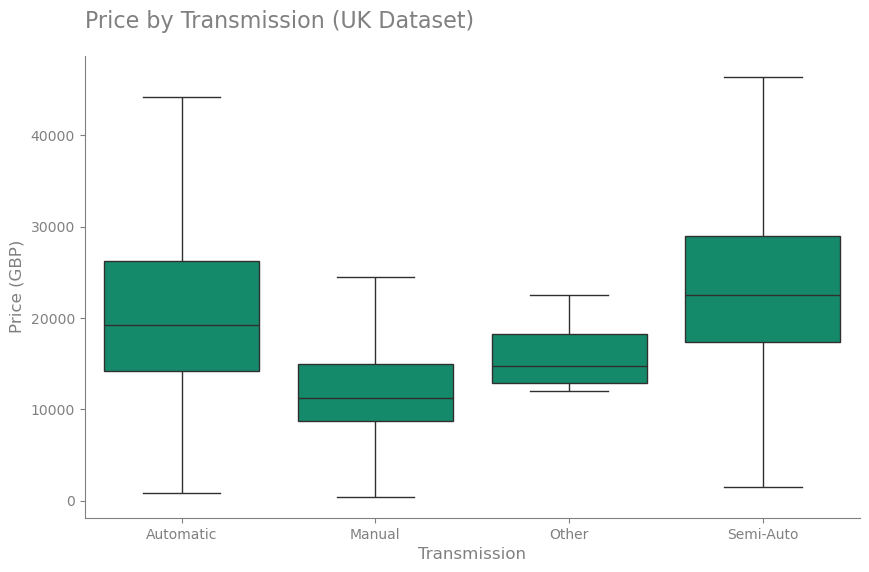

In [19]:
# Set figure size [cite: 132]
fig, ax = plt.subplots(figsize=(10, 6))

# Generate boxplots [cite: 13]
sns.boxplot(data=dfs['uk_dataset'], x='transmission', y='price', color=okabe_ito[2], showfliers=False, ax=ax)

# Add descriptive labels and title [cite: 341, 345]
ax.set_title('Price by Transmission (UK Dataset)', loc='left', fontsize=16, color='grey', pad=20)
ax.set_xlabel('Transmission', color='grey', fontsize=12)
ax.set_ylabel('Price (GBP)', color='grey', fontsize=12)

# Remove top and right lines [cite: 171, 172, 311, 312]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text [cite: 174, 175, 314]
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Save graph
plt.savefig('price_transmission_uk.png', dpi=300, bbox_inches='tight')

# Show boxplots
plt.show()

##### Price Distribution by Fuel Type

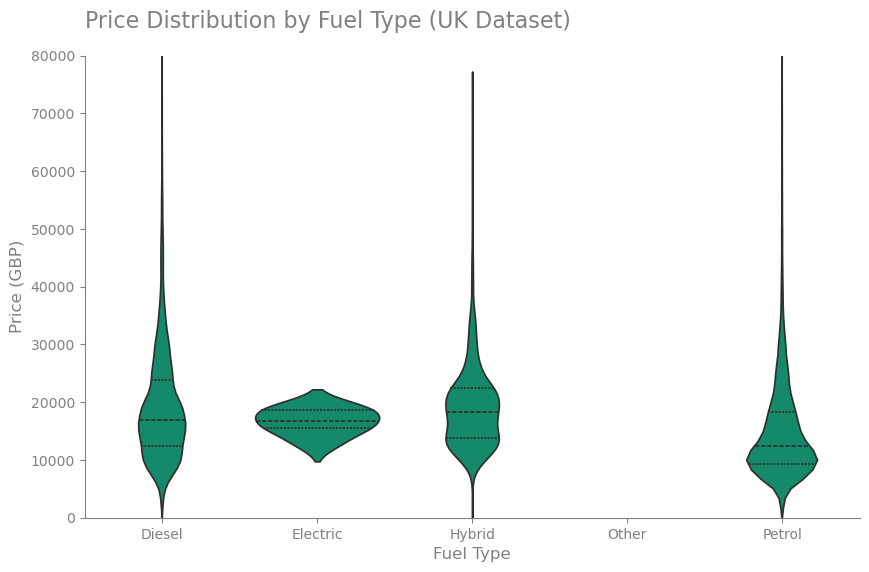

In [20]:
# Set figure size for the price by fuel type analysis using the object-oriented interface
fig, ax = plt.subplots(figsize=(10, 6))

# Define a list of common fuel types for filtering
common_fuels = ['Petrol', 'Diesel', 'Hybrid', 'Electric']

# Filter the UK dataset to include only the specified common fuel types
df_uk_fuel = dfs['uk_dataset'][dfs['uk_dataset']['fuelType'].isin(common_fuels)]

# Generate a violin plot using the colorblind-safe Okabe-Ito palette
sns.violinplot(
    data=df_uk_fuel, 
    x='fuelType', 
    y='price', 
    color=okabe_ito[2], 
    inner='quartile',
    ax=ax
)

# Set the title for the fuel type distribution plot aligned left
ax.set_title('Price Distribution by Fuel Type (UK Dataset)', loc='left', color='grey', fontsize=16, pad=20)

# Set the x-axis label for fuel types with grey text
ax.set_xlabel('Fuel Type', color='grey', fontsize=12)

# Set the y-axis label for price (GBP) with grey text
ax.set_ylabel('Price (GBP)', color='grey', fontsize=12)

# Set the y-axis limit to handle outliers and ensure a zero baseline
ax.set_ylim(0, 80000)

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Save graph
plt.savefig('price_fuelType_uk.png', dpi=300, bbox_inches='tight')

# Show the violin plot
plt.show()

##### Price vs. Fuel Efficiency (MPG)

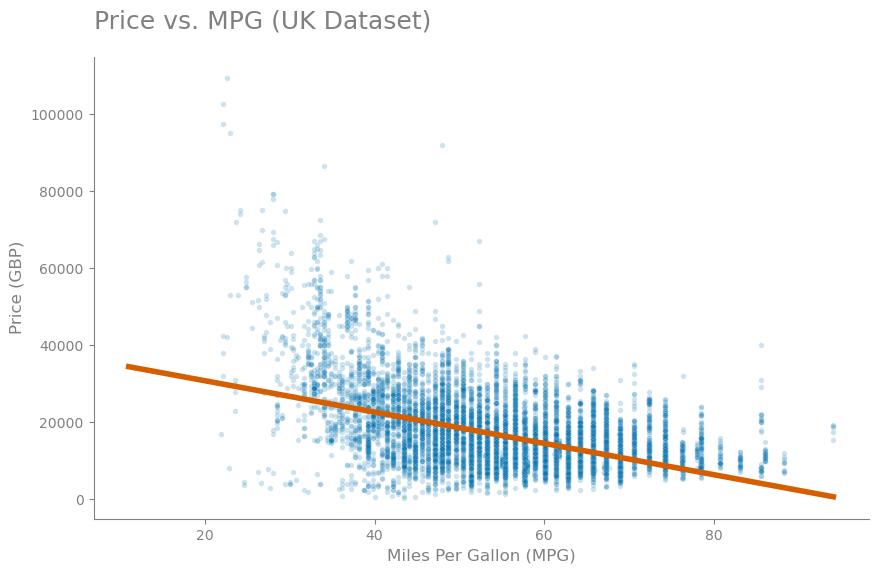

In [21]:
# Set figure size for the scatter plot using the object-oriented interface
fig, ax = plt.subplots(figsize=(10, 6))

# Filter the UK dataset to include only realistic MPG values (between 10 and 100)
df_uk_mpg = dfs['uk_dataset'][(dfs['uk_dataset']['mpg'] > 10) & (dfs['uk_dataset']['mpg'] < 100)]

# Generate scatter plot using Okabe-Ito Blue with low alpha to reduce cognitive load
sns.scatterplot(
    data=df_uk_mpg.sample(min(10000, len(df_uk_mpg))), 
    x='mpg', 
    y='price', 
    alpha=0.2, 
    s=15, 
    color=okabe_ito[4],
    ax=ax,
    zorder=1
)

# Add a linear regression line in Okabe-Ito Vermillion with increased thickness and zorder for visibility
sns.regplot(
    data=df_uk_mpg, 
    x='mpg', 
    y='price', 
    scatter=False, 
    color=okabe_ito[5], 
    line_kws={"linewidth": 4, "zorder": 5},
    ax=ax
)

# Add descriptive labels and title aligned left with grey text to reduce eye-travel
ax.set_title('Price vs. MPG (UK Dataset)', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Miles Per Gallon (MPG)', color='grey', fontsize=12)
ax.set_ylabel('Price (GBP)', color='grey', fontsize=12)

# Remove top and right lines to apply the Gestalt principle of Closure
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines to reduce visual noise
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show scatterplot
plt.show()

### Andrei Dataset

#### Univariate Analysis

##### Price and Mileage Distribution

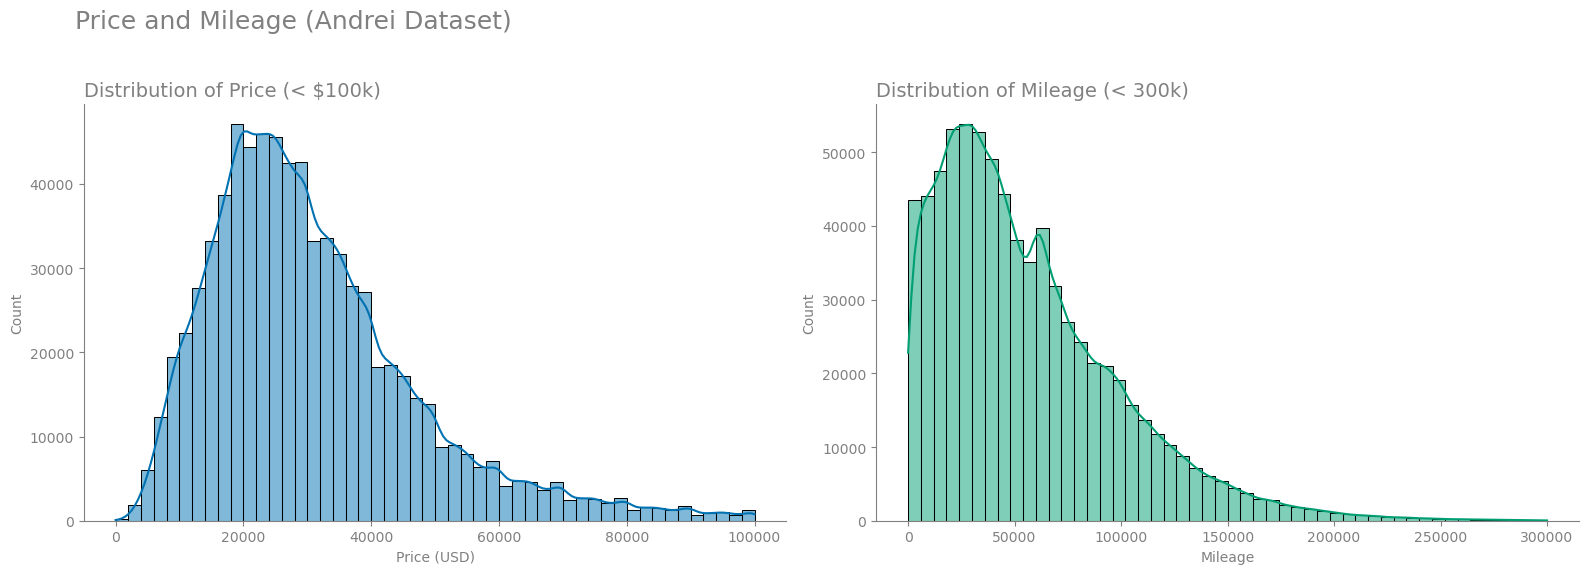

In [22]:
# Create a mask to handle outliers price < 100000 and milage < 300000
vis_mask = (dfs['andrei_dataset']['price'] < 100000) & (dfs['andrei_dataset']['mileage'] < 300000)

# Apply the mask to create a filtered dataframe
df_andrei = dfs['andrei_dataset'][vis_mask]

# Initialize subplots for price and mileage distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Set the main title for the combined plots aligned left with grey text
fig.suptitle('Price and Mileage (Andrei Dataset)', 
             fontsize=18, x=0.05, ha='left', color='grey')

# Generate histogram and KDE for price distribution using Okabe-Ito Vermillion
sns.histplot(df_andrei['price'], bins=50, kde=True, ax=axes[0], color=okabe_ito[4])

# Set individual plot title and axis labels for price with grey formatting
axes[0].set_title('Distribution of Price (< $100k)', loc='left', color='grey', fontsize=14)
axes[0].set_xlabel('Price (USD)', color='grey')
axes[0].set_ylabel('Count', color='grey')

# Generate histogram and KDE for mileage distribution using Okabe-Ito Blue
sns.histplot(df_andrei['mileage'], bins=50, kde=True, ax=axes[1], color=okabe_ito[2])

# Set individual plot title and axis labels for mileage with grey formatting
axes[1].set_title('Distribution of Mileage (< 300k)', loc='left', color='grey', fontsize=14)
axes[1].set_xlabel('Mileage', color='grey')
axes[1].set_ylabel('Count', color='grey')

# Refine visual interface by stripping clutter and applying grey tones
for ax in axes:
    # Remove top and right spines to reduce extraneous cognitive load
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Lighten remaining spines and ticks to let the data be the main focus
    ax.spines['left'].set_color('grey')
    ax.spines['bottom'].set_color('grey')
    ax.tick_params(colors='grey')

# Adjust layout to prevent overlapping and display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save graph
plt.savefig('price_milage_dist_andrei.png', dpi=300, bbox_inches='tight')

# Show distribution plots
plt.show()

##### Transmission and Fuel Type Count

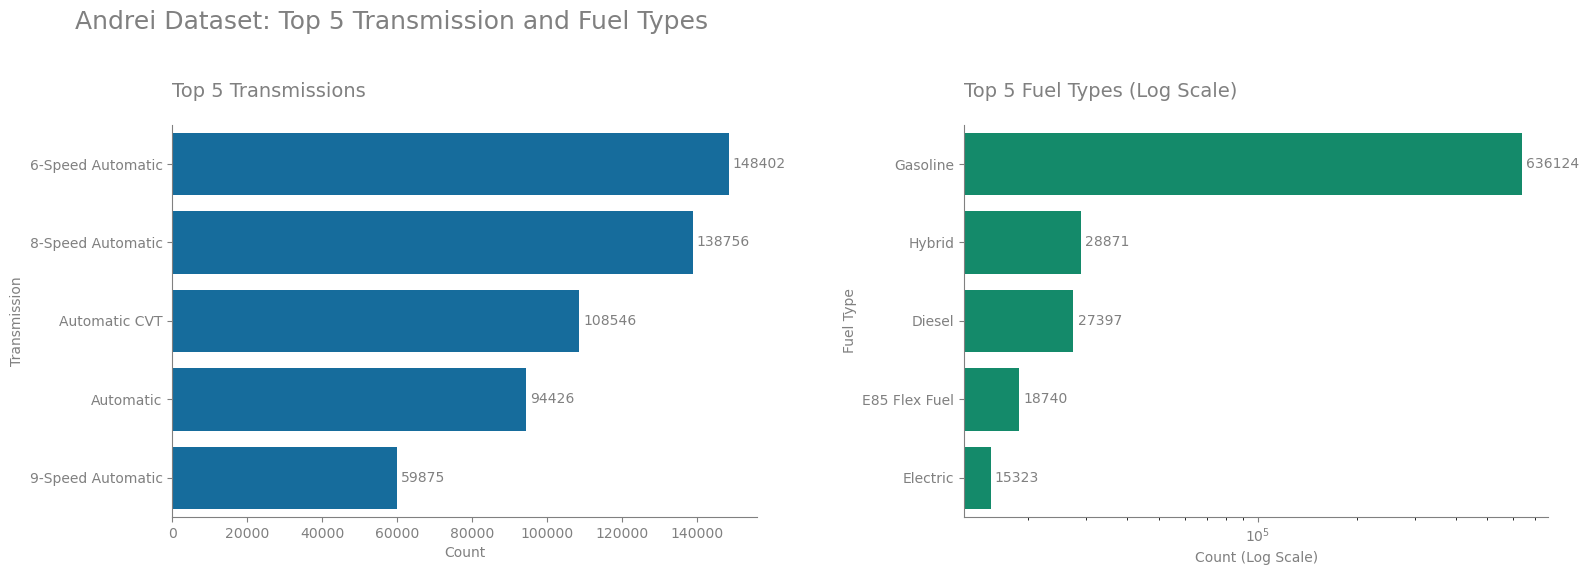

In [23]:
# Initialize subplots for transmission and fuel type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Set the main title for the categorical plots aligned left with grey text
fig.suptitle('Andrei Dataset: Top 5 Transmission and Fuel Types', 
             fontsize=18, x=0.05, ha='left', color='grey')

# Identify the top 5 most frequent transmission types
top_trans = df_andrei['transmission'].value_counts().nlargest(5).index

# Generate horizontal count plot using the colorblind-safe Okabe-Ito palette
sns.countplot(
    data=df_andrei[df_andrei['transmission'].isin(top_trans)], 
    y='transmission', 
    order=top_trans, 
    ax=axes[0], 
    color=okabe_ito[4]
)

# Set individual plot title for transmission with grey formatting and padding
axes[0].set_title('Top 5 Transmissions', loc='left', color='grey', fontsize=14, pad=20)
axes[0].set_xlabel('Count', color='grey')
axes[0].set_ylabel('Transmission', color='grey')

# Annotate bars with frequency labels using grey text to apply Proximity
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, color='grey')

# Identify the top 5 most frequent fuel types
top_fuel = df_andrei['fuel_type'].value_counts().nlargest(5).index

# Generate horizontal count plot for the top 5 fuel types
sns.countplot(
    data=df_andrei[df_andrei['fuel_type'].isin(top_fuel)], 
    y='fuel_type', 
    order=top_fuel, 
    ax=axes[1], 
    color=okabe_ito[2]
)

# Set individual plot title and apply log scale to the x-axis with grey formatting
axes[1].set_title('Top 5 Fuel Types (Log Scale)', loc='left', color='grey', fontsize=14, pad=20)
axes[1].set_xscale('log')
axes[1].set_xlabel('Count (Log Scale)', color='grey')
axes[1].set_ylabel('Fuel Type', color='grey')

# Annotate bars with frequency labels using grey text
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, color='grey')

# Refine visual interface by stripping clutter and applying grey tones
for ax in axes:
    # Remove top and right spines to apply the principle of Closure
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Lighten remaining spines and ticks to reduce visual noise
    ax.spines['left'].set_color('grey')
    ax.spines['bottom'].set_color('grey')
    ax.tick_params(colors='grey')

# Adjust layout with increased horizontal spacing between subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95], w_pad=4.0)

# Save graph
plt.savefig('transmission_fuelType_andrei.png', dpi=300, bbox_inches='tight')

# Show countplots
plt.show()

##### Make and Model Distribution

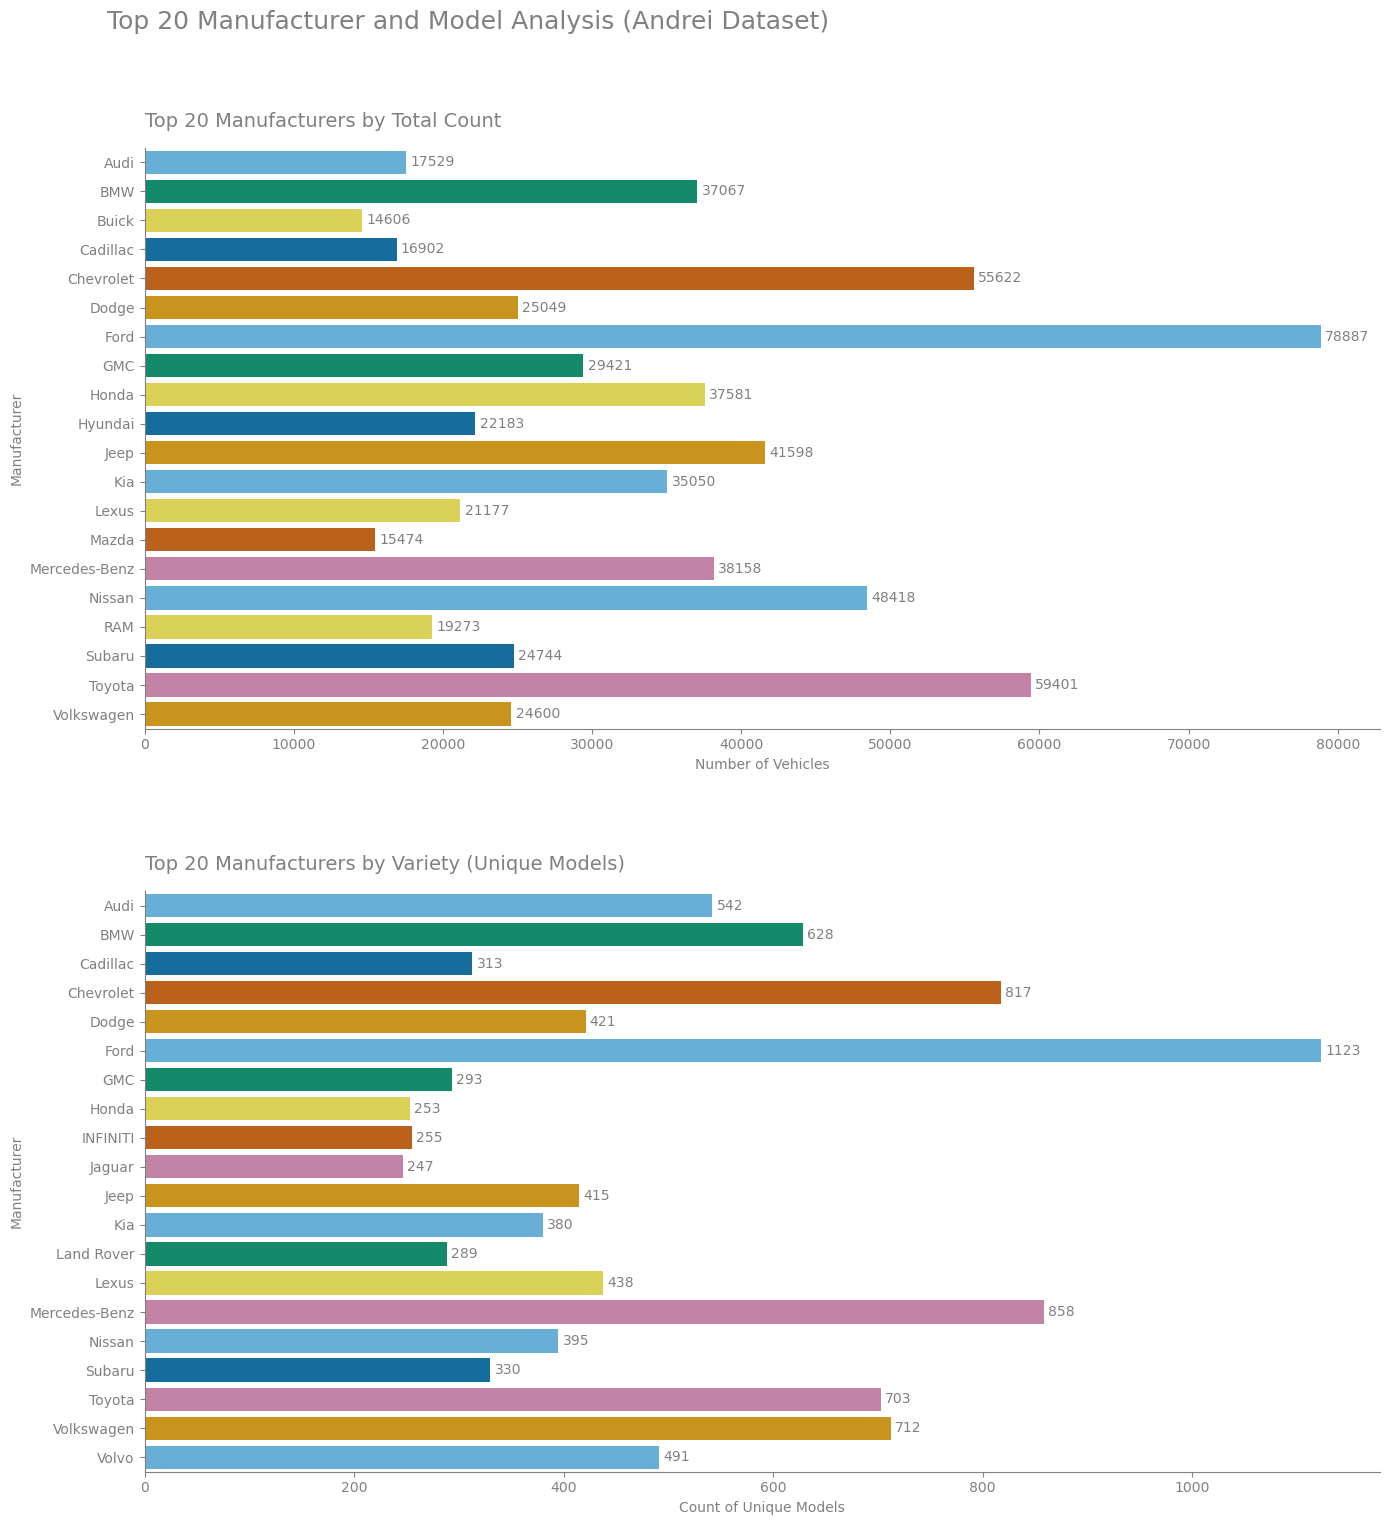

In [24]:
# Initialize subplots for manufacturer and model variety analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# Set the main title for the manufacturer-level overview - Aligned left
fig.suptitle('Top 20 Manufacturer and Model Analysis (Andrei Dataset)', 
             fontsize=18, x=0.08, ha='left', color='grey')

# Identify the top 20 manufacturers by total vehicle count
make_order = df_andrei['manufacturer'].value_counts().nlargest(20).index.sort_values()

all_brands = df_andrei['manufacturer'].dropna().unique()
brand_palette = {brand: okabe_ito[i % len(okabe_ito)] for i, brand in enumerate(all_brands)}

# Generate horizontal count plot using okabe_ito palette
sns.countplot(
    data=df_andrei[df_andrei['manufacturer'].isin(make_order)], 
    y='manufacturer', 
    order=make_order, 
    ax=axes[0], 
    palette=brand_palette,
    hue='manufacturer',
    dodge=False,
    legend=False
)

# Set individual plot title and axis labels for manufacturer counts - Left-aligned with grey text
axes[0].set_title('Top 20 Manufacturers by Total Count', loc='left', color='grey', fontsize=14, pad=15)
axes[0].set_xlabel('Number of Vehicles', color='grey')
axes[0].set_ylabel('Manufacturer', color='grey')

# Annotate bars with total vehicle counts per manufacturer using grey text
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, color='grey')

# Calculate number of unique models and filter to keep only the top 20 with variety > 0
unique_models = df_andrei.groupby('manufacturer')['model'].nunique()
unique_models = unique_models[unique_models > 0].sort_values(ascending=False).head(20).sort_index()

# Generate horizontal bar plot for unique model counts using okabe_ito palette
sns.barplot(
    x=unique_models.values, 
    y=unique_models.index, 
    ax=axes[1], 
    palette=brand_palette, 
    order=unique_models.index,
    hue=unique_models.index,
    dodge=False,
    legend=False
)

# Set individual plot title and labels for unique model counts - Left-aligned with grey text
axes[1].set_title('Top 20 Manufacturers by Variety (Unique Models)', loc='left', color='grey', fontsize=14, pad=15)
axes[1].set_xlabel('Count of Unique Models', color='grey')
axes[1].set_ylabel('Manufacturer', color='grey')

# Annotate bars with the specific count of unique models using grey text
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, color='grey')

# Refine visual interface by removing top and right splines and using grey tones
for ax in axes:
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Lighten remaining spines and ticks
    ax.spines['left'].set_color('grey')
    ax.spines['bottom'].set_color('grey')
    ax.tick_params(colors='grey')

# Optimize layout with increased vertical spacing between subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=6.0)

# Save graph
plt.savefig('make_model_andrei.png', dpi=300, bbox_inches='tight')

# Show barplots
plt.show()

#### Bivariate/Multivariate Analysis

##### Price by Manufacturer

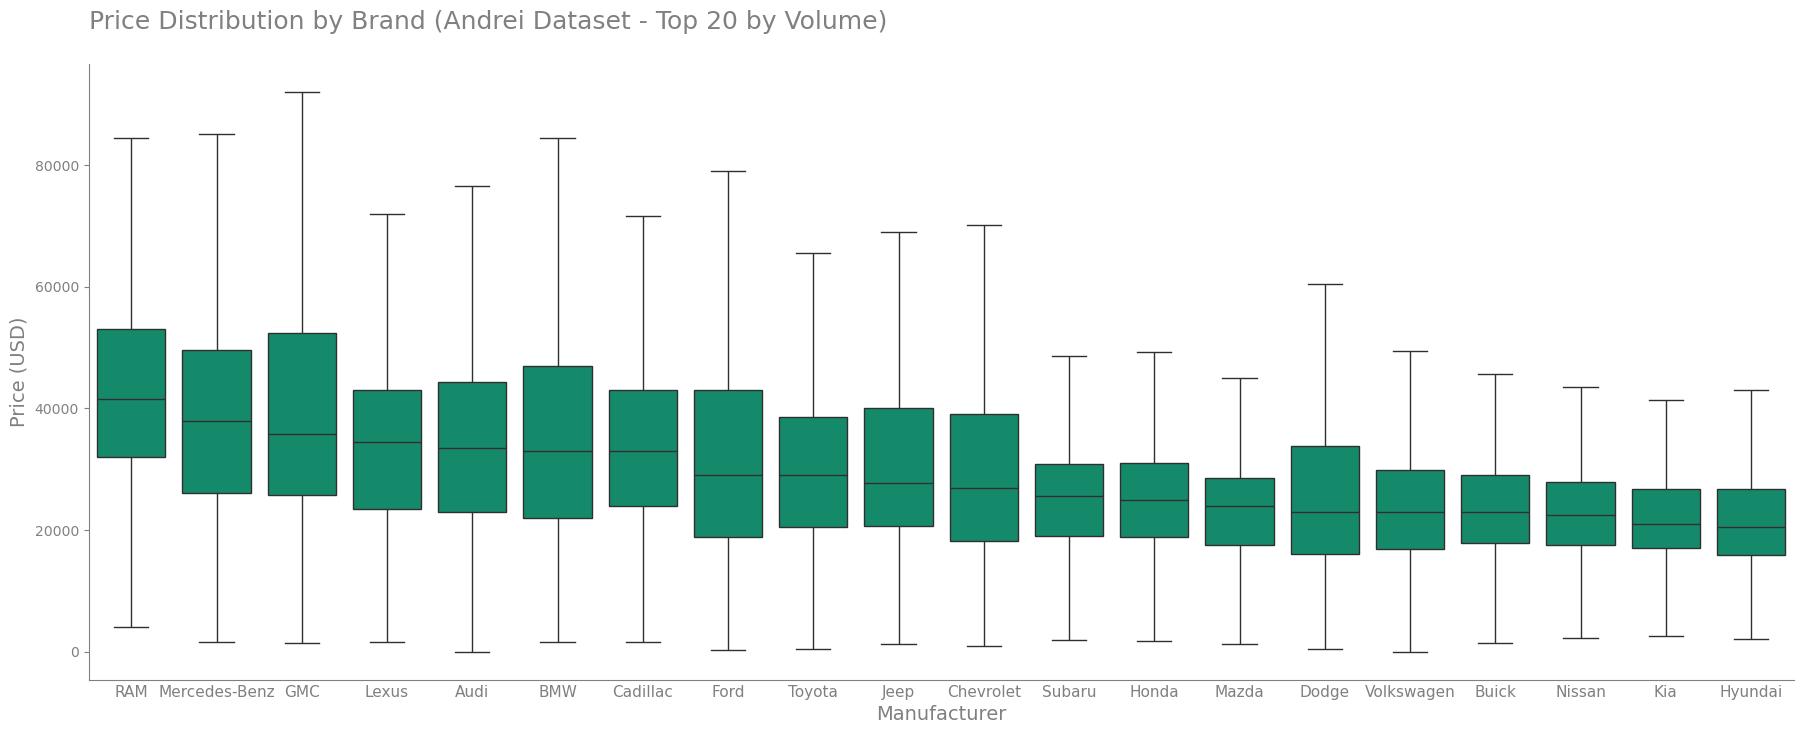

In [25]:
# Set figure size - Widened significantly to 22 inches to fit all manufacturer names horizontally without clashing
fig, ax = plt.subplots(figsize=(22, 8))

# Identify the top 20 manufacturers by vehicle volume
top_20_makes = df_andrei['manufacturer'].value_counts().nlargest(20).index

# Filter the dataset to include only the top 20 manufacturers
df_andrei_top20 = df_andrei[df_andrei['manufacturer'].isin(top_20_makes)]

# Calculate the median price per manufacturer to determine plot order
order_andrei = df_andrei_top20.groupby('manufacturer')['price'].median().sort_values(ascending=False).index

# Generate boxplots
sns.boxplot(
    data=df_andrei_top20, 
    x='manufacturer', 
    y='price', 
    order=order_andrei,
    color=okabe_ito[2], 
    showfliers=False,
    ax=ax
)

# Set title to the left with grey text
ax.set_title('Price Distribution by Brand (Andrei Dataset - Top 20 by Volume)', 
             loc='left', fontsize=18, color='grey', pad=25)

# Set labels with grey text
ax.set_xlabel('Manufacturer', color='grey', fontsize=14)
ax.set_ylabel('Price (USD)', color='grey', fontsize=14)

# Keep manufacturer labels horizontal and remove x-axis ticks to reduce visual noise
ax.tick_params(axis='x', rotation=0, length=0, colors='grey', labelsize=11)
ax.tick_params(axis='y', colors='grey')

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Lighten remaining spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')

# Save graph
plt.savefig('price_make_andrei.png', dpi=300, bbox_inches='tight')

# Show the boxplot
plt.show()

##### Price vs Milage

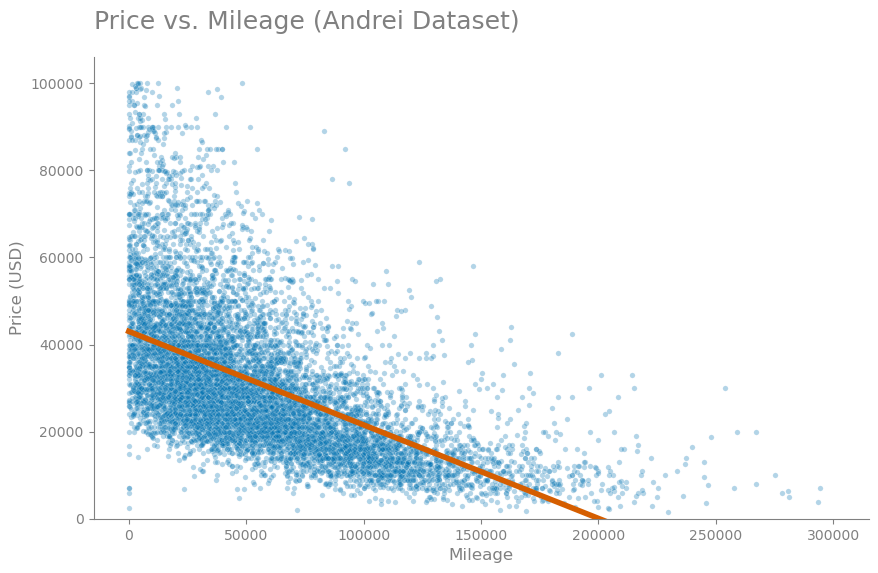

In [26]:
# Create a mask to filter out outliers
vis_mask = (dfs['andrei_dataset']['price'] < 100000) & (dfs['andrei_dataset']['mileage'] < 300000)

# Apply the mask to create a filtered dataframe
df_andrei = dfs['andrei_dataset'][vis_mask]

# Set figure size for the scatter plot using the object-oriented interface
fig, ax = plt.subplots(figsize=(10, 6))

# Generate scatter plot using Okabe-Ito Blue
sns.scatterplot(
    data=df_andrei.sample(min(10000, len(df_andrei))), 
    x='mileage', 
    y='price', 
    alpha=0.3, 
    s=15, 
    color=okabe_ito[4],
    ax=ax,
    zorder=1
)

# Add a linear regression line in Okabe-Ito Vermillion to show the general trend
sns.regplot(
    data=df_andrei, 
    x='mileage', 
    y='price', 
    scatter=False, 
    color=okabe_ito[5], 
    line_kws={"linewidth": 4, "zorder": 5},
    ax=ax
)

# Set the lower limit of the y-axis to 0
ax.set_ylim(bottom=0)

# Add descriptive labels and title aligned left with grey text
ax.set_title('Price vs. Mileage (Andrei Dataset)', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Mileage', color='grey', fontsize=12)
ax.set_ylabel('Price (USD)', color='grey', fontsize=12)

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Save graph
plt.savefig('price_milage_andrei.png', dpi=300, bbox_inches='tight')

# Show scatterplot
plt.show()

##### Accident Count

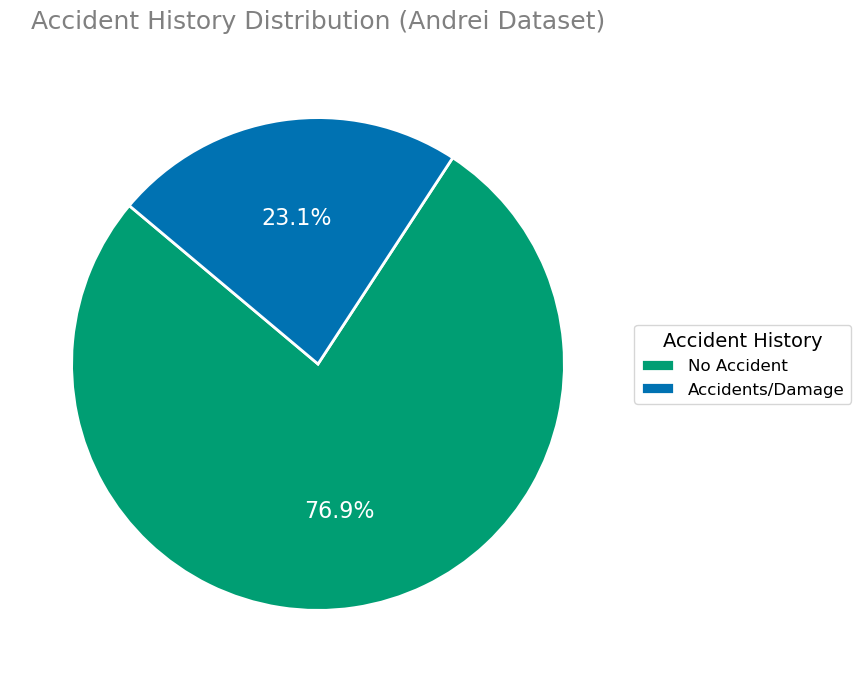

In [27]:
# Prepare data for the pie chart
accident_counts = df_andrei['accidents_or_damage'].value_counts()
labels = ['No Accident', 'Accidents/Damage']

# Set figure size for the pie chart using the object-oriented interface
fig, ax = plt.subplots(figsize=(10, 8)) # Increased width slightly for legend space

# Generate pie chart
# Note: I've kept labels=None in the pie call so they only appear in the legend
wedges, texts, autotexts = ax.pie(
    accident_counts, 
    autopct='%1.1f%%', 
    startangle=140,
    colors=[okabe_ito[2], okabe_ito[4]],
    textprops={'color': 'white', 'fontsize': 16},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Add the legend
# loc="center left" and bbox_to_anchor=(1, 0, 0.5, 1) moves it to the right of the plot
ax.legend(
    wedges, 
    labels,
    title="Accident History",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=12,
    title_fontsize=14
)

# Add descriptive title aligned left with grey text
ax.set_title('Accident History Distribution (Andrei Dataset)', color='grey', fontsize=18, pad=20)

# Save graph
plt.savefig('accident_pie_andrei.png', dpi=300, bbox_inches='tight')

# Show pie chart
plt.show()

##### Price to Accident Ratio

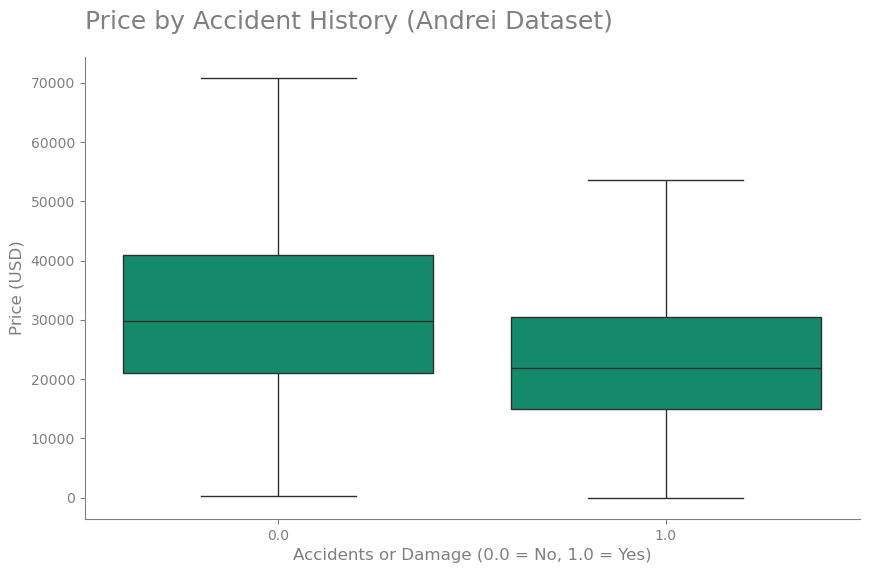

In [28]:
# Set figure size for the boxplot using the object-oriented interface
fig, ax = plt.subplots(figsize=(10, 6))

# Generate boxplots to compare price distributions based on accident history
sns.boxplot(
    data=df_andrei, 
    x='accidents_or_damage', 
    y='price', 
    color=okabe_ito[2], 
    showfliers=False,
    ax=ax
)

# Add descriptive labels and title aligned left with grey text
ax.set_title('Price by Accident History (Andrei Dataset)', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Accidents or Damage (0.0 = No, 1.0 = Yes)', color='grey', fontsize=12)
ax.set_ylabel('Price (USD)', color='grey', fontsize=12)

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Save graph
plt.savefig('price_accident_andrei.png', dpi=300, bbox_inches='tight')

# Show boxplots
plt.show()

##### Correlation Matrix

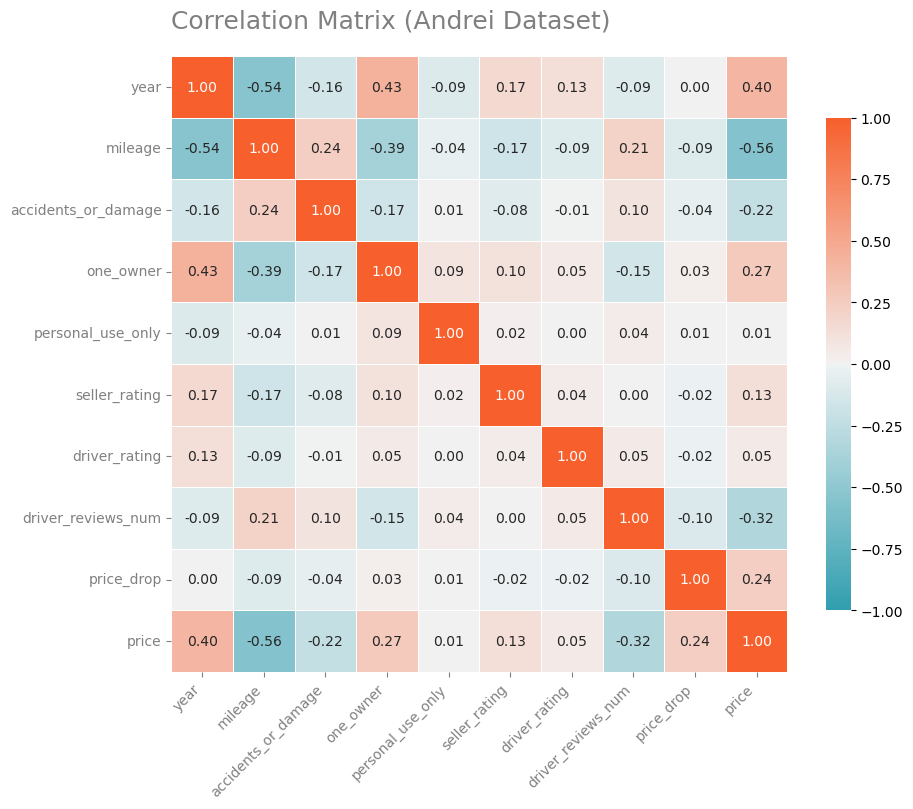

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the numerical columns for correlation analysis
num_cols_andrei = df_andrei.select_dtypes(include=[np.number]).columns

# Calculate the Pearson correlation coefficients for the numerical features
corr_andrei = df_andrei[num_cols_andrei].corr()

# Set figure size for the correlation heatmap using the object-oriented interface
fig, ax = plt.subplots(figsize=(10, 8))

# Create a vibrant colorblind-friendly diverging palette 
vibrant_cb_palette = sns.diverging_palette(h_neg=210, h_pos=20, s=90, l=60, as_cmap=True)

# Generate heatmap with enhanced visibility and clear annotations
sns.heatmap(
    corr_andrei, 
    annot=True, 
    cmap=vibrant_cb_palette, 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    ax=ax
)

# Set the title for the correlation matrix plot aligned left with grey text
ax.set_title('Correlation Matrix (Andrei Dataset)', loc='left', color='grey', fontsize=18, pad=20)

# Set tick colors to grey
ax.tick_params(colors='grey')

# Rotate the x-axis labels by 45 degrees and align to the right
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation=45, 
    horizontalalignment='right', 
    color='grey'
)

# Keep y-axis labels grey
ax.set_yticklabels(ax.get_yticklabels(), color='grey')

# Remove the outer spines to simplify the visual interface
for spine in ax.spines.values():
    spine.set_visible(False)

# Save graph
plt.savefig('heatmap_andrei.png', dpi=300, bbox_inches='tight')

# Show heatmap
plt.show()

##### Price vs Milage Hexbin

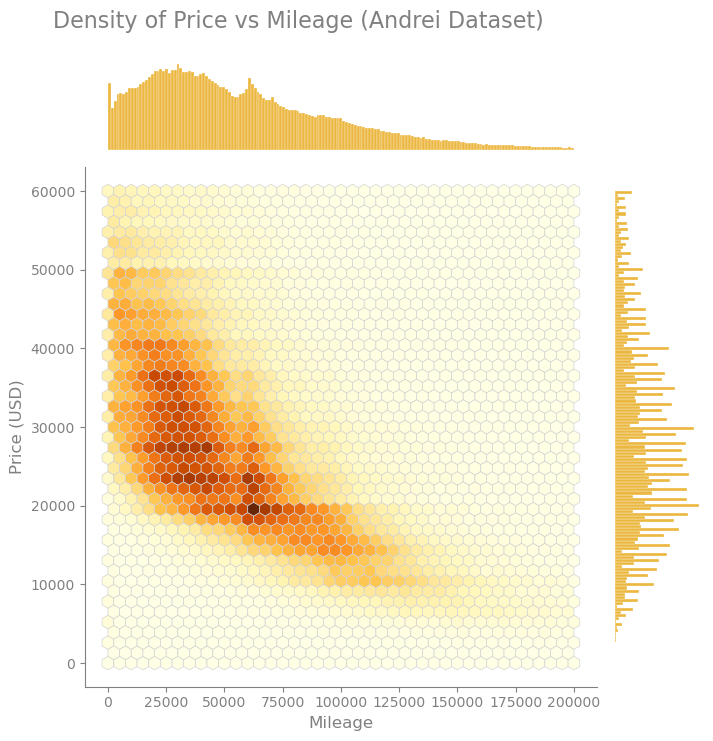

In [30]:
# Create a hex mask for price < 60000 and milage < 200000
andrei_hex_mask = (df_andrei['price'] < 60000) & (df_andrei['mileage'] < 200000)

# Extract price and milage data
andrei_hex_data = df_andrei[andrei_hex_mask]

# Generate hexbin plot using jointplot with outlines added to the hexbins
g = sns.jointplot(
    data=andrei_hex_data, 
    x='mileage', 
    y='price', 
    kind='hex', 
    cmap='YlOrBr', 
    gridsize=40, 
    height=7,
    joint_kws={'edgecolors': 'lightgrey', 'linewidths': 0.5},
    marginal_kws={'color': okabe_ito[0], 'edgecolor': 'white'}
)

# Set axis labels
g.ax_joint.set_xlabel('Mileage', color='grey', fontsize=12)
g.ax_joint.set_ylabel('Price (USD)', color='grey', fontsize=12)

# Set title for hexbin plot
plt.suptitle("Density of Price vs Mileage (Andrei Dataset)", 
             x=0.05, y=1.05, ha='left', fontsize=16, color='grey')

# Remove top and right lines
g.ax_joint.spines['top'].set_visible(False)
g.ax_joint.spines['right'].set_visible(False)
g.ax_joint.spines['left'].set_color('grey')
g.ax_joint.spines['bottom'].set_color('grey')
g.ax_joint.tick_params(colors='grey')

# Clean up marginal axes
for ax in [g.ax_marg_x, g.ax_marg_y]:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='grey', length=0)

# Save graph
plt.savefig('hex_price_milage_andrei.png', dpi=300, bbox_inches='tight')

# Show hexbin plot
plt.show()

## Verify Data Quality

In [31]:
for name, df in dfs.items():
    # Check for feature missing values
    missing = df.isnull().sum()
    # Check for the dataset's total missing value
    total_missing = missing.sum()

    # Check for duplicate records
    duplicates = df.duplicated().sum()

    # Check for dataset name to set max year based on the date of the dataset
    match name:
        case "uk_dataset":
            max_year = 2020
        case "andrei_dataset":
            max_year = 2023
        case _:
            max_year = 2026

    # if a dataset happens to be missing the 'year' or 'engineSize' columns.
    future_cars = 0
    engine_check = 0

    # Check if year exists as a feature in the dataset
    if 'year' in df.columns:
        # Extract future car error based on a boolean mask
        future_cars = df[df['year'] > max_year].shape[0]

    # Check if engine size exists as a feature in the dataset
    if 'engineSize' in df.columns:
        engine_check = df[(df['engineSize'] < 0.6) | (df['engineSize'] > 8.0)].shape[0]

    # Print summary for dataset
    print(f'\n{"="*20} {name} {"="*20}')
    print(f"Total Rows: {len(df):,}")
    
    print(f"Duplicate Rows: {duplicates:,} ({(duplicates/len(df))*100:.2f}%)")
    print(f"Future Year Entries (>{max_year}): {future_cars}")
    if engine_check > 0:
        print(f"Zero Engine Size Entries: {engine_check}")

    for col in df.columns:
        # Gather feature metrics
        dtype_info = df[col].dtype
        missing_count = missing[col]
        
        # Calculate missing percentage per feature
        if len(df) > 0:
            missing_percentage = (missing_count / len(df)) * 100
        else:
            missing_percentage = 0.0
        
        # Print feature metrics
        print(f"Column: {col:<15} | "
            f"Type: {str(dtype_info):<10} | "
            f"Missing: {missing_count:<6} | "
            f"Percentage: {missing_percentage:.2f}%")


==================== uk_dataset ====================
Total Rows: 108,540
Duplicate Rows: 2,273 (2.09%)
Future Year Entries (>2020): 1
Zero Engine Size Entries: 286
Column: model           | Type: category   | Missing: 0      | Percentage: 0.00%
Column: year            | Type: int32      | Missing: 0      | Percentage: 0.00%
Column: price           | Type: int32      | Missing: 0      | Percentage: 0.00%
Column: transmission    | Type: category   | Missing: 0      | Percentage: 0.00%
Column: mileage         | Type: int32      | Missing: 0      | Percentage: 0.00%
Column: fuelType        | Type: category   | Missing: 0      | Percentage: 0.00%
Column: tax             | Type: float32    | Missing: 9353   | Percentage: 8.62%
Column: mpg             | Type: float32    | Missing: 9353   | Percentage: 8.62%
Column: engineSize      | Type: float32    | Missing: 0      | Percentage: 0.00%
Column: make            | Type: category   | Missing: 0      | Percentage: 0.00%

==================== and